# Direct TPX3 to Neutrons Conversion (Updated)

This notebook demonstrates how to directly convert raw TPX3 data to neutron events using TDCSophiread's new API.

**🚀 Key Features:**
- Zero-copy memory optimization with `TDCNeutronView`
- Updated configuration structure using `NeutronProcessingConfig`
- Chunk-based memory mapping for improved memory efficiency
- 8x super-resolution with sub-pixel precision

The workflow is straightforward:
1. Load TPX3 file
2. Apply clustering with configurable parameters
3. Extract neutron events with sub-pixel resolution
4. Visualize results with 2D histograms and TOF spectra

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

# Import TDCSophiread
import tdcsophiread as tdc

print(f"TDCSophiread version: {tdc.__version__}")

TDCSophiread version: 2.0.0


## Configure Neutron Processing Parameters

In [2]:
# Start with VENUS detector defaults
config = tdc.NeutronProcessingConfig.venus_defaults()

# Adjust clustering parameters for optimal performance
config.clustering.abs.radius = 5.0  # Spatial clustering radius in pixels
config.clustering.abs.neutron_correlation_window = 75.0  # Time window in nanoseconds
config.extraction.super_resolution_factor = 8.0  # 8x super-resolution
config.extraction.weighted_by_tot = True  # Use TOT weighting
config.extraction.min_tot_threshold = 0  # No TOT filtering
config.temporal.enable_deduplication = False  # Disable deduplication for performance

print("Neutron Processing Configuration:")
print(f"  Clustering algorithm: {config.clustering.algorithm}")
print(f"  Spatial radius: {config.clustering.abs.radius} pixels")
print(f"  Time window: {config.clustering.abs.neutron_correlation_window} ns")
print(f"  Super-resolution: {config.extraction.super_resolution_factor}x")
print(f"  TOT weighting: {config.extraction.weighted_by_tot}")
print(f"  Min TOT threshold: {config.extraction.min_tot_threshold}")

Neutron Processing Configuration:
  Clustering algorithm: abs
  Spatial radius: 5.0 pixels
  Time window: 75.0 ns
  Super-resolution: 8.0x
  TOT weighting: True
  Min TOT threshold: 0


## Select TPX3 Data File

In [3]:
# Available test files
data_files = {
    "Ni": "data/Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3",
    "tiny": "data/tiny.tpx3",
}

# Find available file
test_file = None
for name, path in data_files.items():
    if Path(path).exists():
        test_file = path
        file_size_mb = Path(test_file).stat().st_size / (1024 * 1024)
        print(f"Found {name} file: {path}")
        print(f"File size: {file_size_mb:.1f} MB")
        break

if test_file is None:
    print("No TPX3 test files found. Please check data directory.")

Found Ni file: data/Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3
File size: 5652.0 MB


## Direct Conversion: TPX3 → Neutrons

Since the legacy `process_tpx3_to_neutrons` function is disabled, we'll implement it using the new API:

In [4]:
def process_tpx3_to_neutrons(
    file_path, parallel=True, num_threads=0, neutron_config=None, detector_config=None
):
    """
    Process TPX3 file directly to neutron events.

    Args:
        file_path: Path to TPX3 file
        parallel: Enable parallel processing
        num_threads: Number of threads (0 = auto-detect)
        neutron_config: NeutronProcessingConfig (defaults to VENUS)
        detector_config: DetectorConfig (defaults to VENUS)

    Returns:
        TDCNeutronView for zero-copy numpy access
    """
    # Use default configurations if not provided
    if neutron_config is None:
        neutron_config = tdc.NeutronProcessingConfig.venus_defaults()
    if detector_config is None:
        detector_config = tdc.DetectorConfig.venus_defaults()

    # Step 1: Process TPX3 file to hits
    print(f"Processing TPX3 file: {file_path}")
    hit_view = tdc.process_tpx3(file_path, parallel=parallel, num_threads=num_threads)
    hits = np.array(hit_view, copy=False)
    print(f"  Extracted {len(hits):,} hits")

    # Step 2: Process hits to neutrons
    print("Clustering hits to neutrons...")
    neutron_view = tdc.process_hits_to_neutrons(hits, neutron_config)
    neutrons = np.array(neutron_view, copy=False)
    print(f"  Found {len(neutrons):,} neutrons")

    return neutron_view

In [5]:
print(f"Processing {test_file}...")
print("=" * 50)

start_time = time.time()

# Direct conversion with our implementation
neutron_view = process_tpx3_to_neutrons(
    file_path=test_file,
    parallel=True,  # Enable parallel processing
    num_threads=0,  # Auto-detect optimal thread count
    neutron_config=config,
)

# Convert to numpy array (zero-copy)
neutrons = np.array(neutron_view, copy=False)

processing_time = time.time() - start_time

# Display results
print(f"\nConversion complete!")
print(f"Time: {processing_time:.2f} seconds")
print(f"Neutrons found: {len(neutrons):,}")
print(f"Processing rate: {file_size_mb / processing_time:.1f} MB/s")
print(f"Neutron rate: {len(neutrons) / processing_time:,.0f} neutrons/s")

Processing data/Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3...
Processing TPX3 file: data/Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3
  Extracted 736,028,562 hits
Clustering hits to neutrons...
  Found 295,145,282 neutrons

Conversion complete!
Time: 18.07 seconds
Neutrons found: 295,145,282
Processing rate: 312.8 MB/s
Neutron rate: 16,331,742 neutrons/s


## Data Summary

In [6]:
if "neutrons" in locals() and neutrons is not None:
    print("Neutron Data Summary")
    print("=" * 40)

    # Spatial information
    print(f"\nSpatial distribution:")
    print(f"  X range: {neutrons['x'].min():.1f} - {neutrons['x'].max():.1f}")
    print(f"  Y range: {neutrons['y'].min():.1f} - {neutrons['y'].max():.1f}")

    # Timing information
    tof_ms = neutrons["tof"] * 25 / 1e6  # Convert to milliseconds
    print(f"\nTiming:")
    print(f"  TOF range: {tof_ms.min():.2f} - {tof_ms.max():.2f} ms")
    print(f"  Mean TOF: {tof_ms.mean():.2f} ms")

    # Clustering statistics
    print(f"\nClustering:")
    print(
        f"  Cluster sizes: {neutrons['n_hits'].min()} - {neutrons['n_hits'].max()} hits/neutron"
    )
    print(f"  Mean cluster size: {neutrons['n_hits'].mean():.2f}")

    # Single vs multi-hit neutrons
    single_hit = np.sum(neutrons["n_hits"] == 1)
    multi_hit = np.sum(neutrons["n_hits"] > 1)
    print(f"\nNeutron types:")
    print(f"  Single-hit: {single_hit:,} ({100 * single_hit / len(neutrons):.1f}%)")
    print(f"  Multi-hit: {multi_hit:,} ({100 * multi_hit / len(neutrons):.1f}%)")

Neutron Data Summary

Spatial distribution:
  X range: 0.0 - 4104.0
  Y range: 0.0 - 4104.0

Timing:
  TOF range: 0.00 - 16.67 ms
  Mean TOF: 6.19 ms

Clustering:
  Cluster sizes: 1 - 71 hits/neutron
  Mean cluster size: 2.49

Neutron types:
  Single-hit: 106,385,763 (36.0%)
  Multi-hit: 188,759,519 (64.0%)


## Visualization: 2D Spatial Distribution


Total neutrons displayed: 295,145,282
Maximum counts per bin: 13832


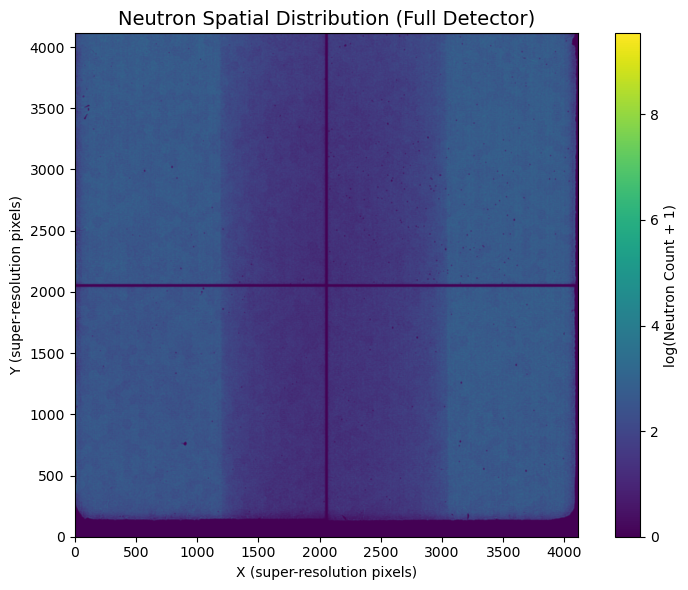

In [7]:
det_venus_config = tdc.DetectorConfig.venus_defaults()

# VENUS detector has 514x514 pixels (256*2 + 2 pixel gap)
DETECTOR_PIXELS = det_venus_config.get_chip_size_x() * 2 + 2

# use super-resolution factor from config
NEUTRON_SUPER_RES = config.extraction.super_resolution_factor

# Calculate super-resolution bins
NEUTRON_BINS = int(DETECTOR_PIXELS * NEUTRON_SUPER_RES)

# visualization
if "neutrons" in locals() and neutrons is not None:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    # Plot 1: Full detector view
    h1, xedges1, yedges1 = np.histogram2d(
        neutrons["x"],
        neutrons["y"],
        bins=NEUTRON_BINS,
        range=[[0, NEUTRON_BINS], [0, NEUTRON_BINS]],
    )

    im1 = ax.imshow(
        np.log1p(h1),
        origin="lower",
        cmap="viridis",
        extent=[xedges1[0], xedges1[-1], yedges1[0], yedges1[-1]],
        interpolation="gaussian",
    )

    ax.set_title("Neutron Spatial Distribution (Full Detector)", fontsize=14)
    ax.set_xlabel("X (super-resolution pixels)")
    ax.set_ylabel("Y (super-resolution pixels)")
    ax.set_aspect("equal")
    plt.colorbar(im1, ax=ax, label="log(Neutron Count + 1)")

    # Print statistics
    print(f"\nTotal neutrons displayed: {len(neutrons):,}")
    print(f"Maximum counts per bin: {int(h1.max())}")

    plt.tight_layout()
    plt.show()

## Visualization: TOF Spectrum

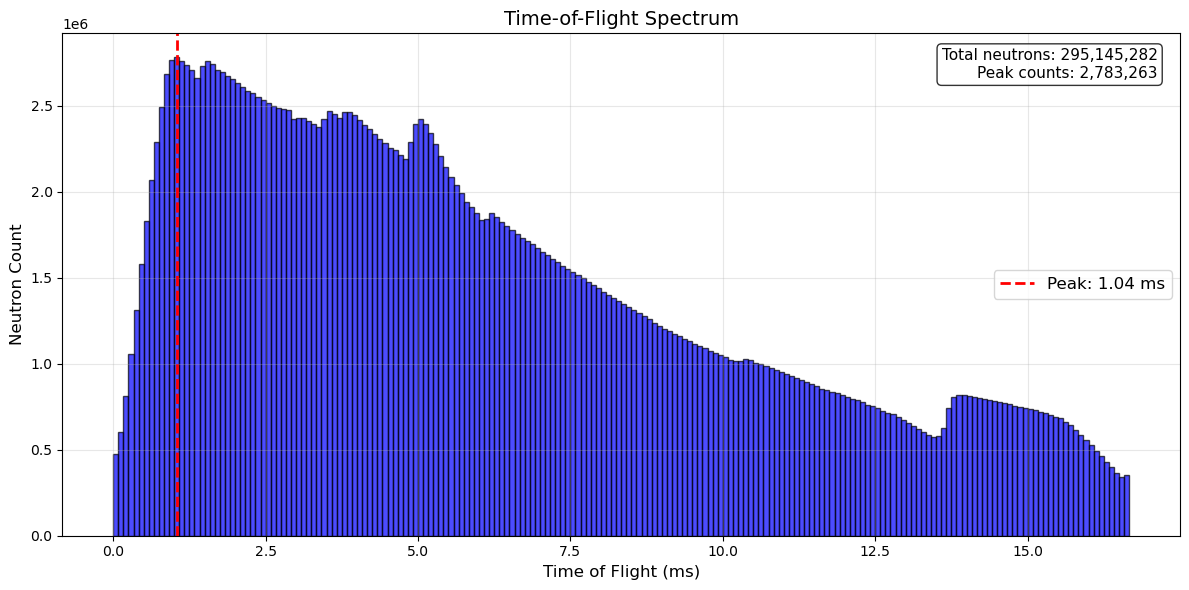


TOF Statistics:
  Range: 0.000 - 16.666 ms
  Mean: 6.193 ms
  Std: 4.251 ms
  Peak: 1.042 ms


In [8]:
if "neutrons" in locals() and neutrons is not None:
    # Convert TOF to milliseconds
    tof_ms = neutrons["tof"] * 25 / 1e6

    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot histogram
    counts, bins, patches = ax.hist(
        tof_ms, bins=200, alpha=0.7, color="blue", edgecolor="black"
    )

    # Find and mark peak
    peak_idx = np.argmax(counts)
    peak_tof = (bins[peak_idx] + bins[peak_idx + 1]) / 2
    peak_counts = counts[peak_idx]

    ax.axvline(
        peak_tof,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Peak: {peak_tof:.2f} ms",
    )

    # Formatting
    ax.set_xlabel("Time of Flight (ms)", fontsize=12)
    ax.set_ylabel("Neutron Count", fontsize=12)
    ax.set_title("Time-of-Flight Spectrum", fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)

    # Add statistics text
    stats_text = f"Total neutrons: {len(tof_ms):,}\nPeak counts: {int(peak_counts):,}"
    ax.text(
        0.98,
        0.97,
        stats_text,
        transform=ax.transAxes,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()

    # Print TOF statistics
    print(f"\nTOF Statistics:")
    print(f"  Range: {tof_ms.min():.3f} - {tof_ms.max():.3f} ms")
    print(f"  Mean: {tof_ms.mean():.3f} ms")
    print(f"  Std: {tof_ms.std():.3f} ms")
    print(f"  Peak: {peak_tof:.3f} ms")

## Visualization: Per-Chip Analysis

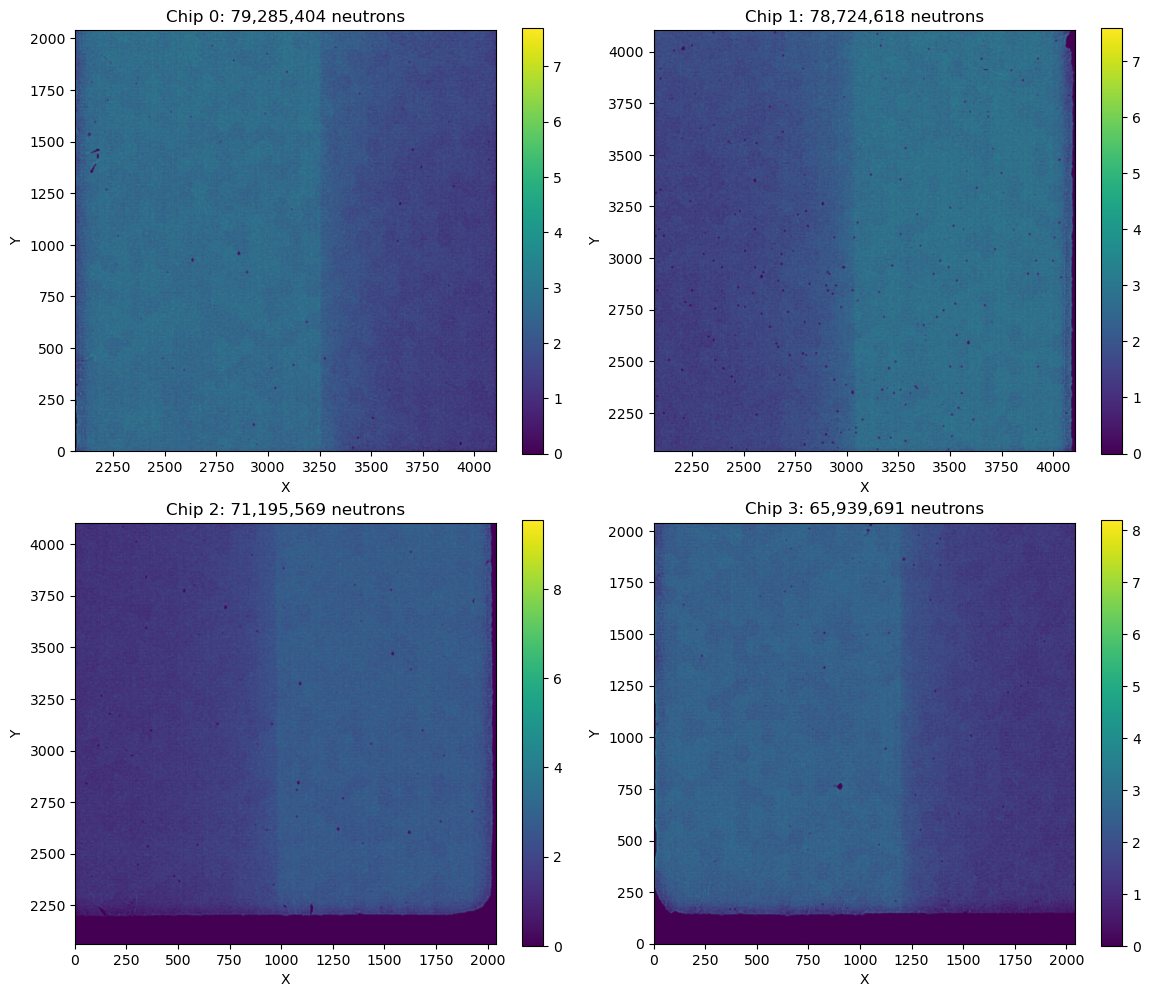


Per-chip neutron distribution:
  Chip 0: 79,285,404 (26.9%)
  Chip 1: 78,724,618 (26.7%)
  Chip 2: 71,195,569 (24.1%)
  Chip 3: 65,939,691 (22.3%)


In [9]:
if "neutrons" in locals() and neutrons is not None:
    # Get unique chips
    unique_chips = np.unique(neutrons["chip_id"])
    n_chips = len(unique_chips)

    if n_chips > 1:
        # Create subplots for each chip
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()

        for i, chip in enumerate(unique_chips[:4]):  # Max 4 chips
            ax = axes[i]

            # Filter data for this chip
            mask = neutrons["chip_id"] == chip
            x_chip = neutrons["x"][mask]
            y_chip = neutrons["y"][mask]

            if len(x_chip) > 0:
                # Create 2D histogram
                # Use super-resolution bins for each chip
                chip_bins = int(det_venus_config.get_chip_size_x() * NEUTRON_SUPER_RES)
                h, xedges, yedges = np.histogram2d(x_chip, y_chip, bins=chip_bins)

                im = ax.imshow(
                    np.log1p(h),
                    origin="lower",
                    cmap="viridis",
                    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                    interpolation="gaussian",
                )

                ax.set_title(f"Chip {chip}: {len(x_chip):,} neutrons", fontsize=12)
                ax.set_xlabel("X")
                ax.set_ylabel("Y")
                ax.set_aspect("equal")
                plt.colorbar(im, ax=ax)
            else:
                ax.text(
                    0.5,
                    0.5,
                    f"Chip {chip}\nNo data",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                )
                ax.set_aspect("equal")

        # Hide unused subplots
        for i in range(n_chips, 4):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

        # Print chip statistics
        print("\nPer-chip neutron distribution:")
        for chip in unique_chips:
            count = np.sum(neutrons["chip_id"] == chip)
            percentage = 100 * count / len(neutrons)
            print(f"  Chip {chip}: {count:,} ({percentage:.1f}%)")
    else:
        print(f"\nAll neutrons on single chip: {unique_chips[0]}")

## Cluster Size Analysis

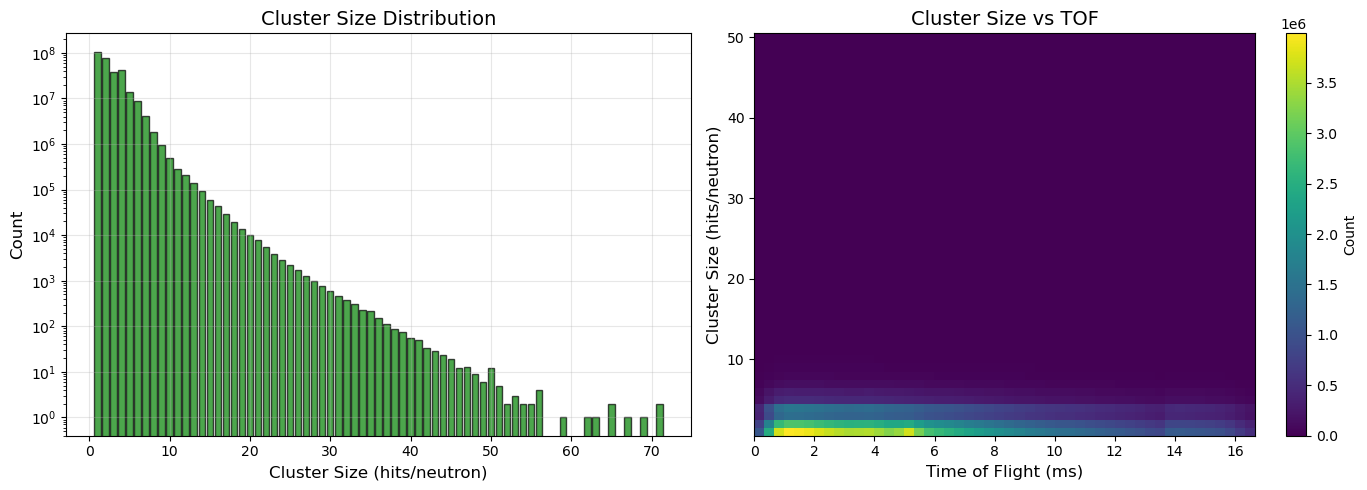


Cluster size statistics:
  1 hits: 106,385,763 neutrons (36.0%)
  2 hits: 77,076,088 neutrons (26.1%)
  3 hits: 38,630,916 neutrons (13.1%)
  4 hits: 42,281,083 neutrons (14.3%)
  5 hits: 13,509,197 neutrons (4.6%)
  6 hits: 8,951,023 neutrons (3.0%)
  7 hits: 4,095,137 neutrons (1.4%)
  8 hits: 1,836,506 neutrons (0.6%)
  9 hits: 972,539 neutrons (0.3%)
  10 hits: 488,944 neutrons (0.2%)
  ... and 53 more sizes


In [10]:
if "neutrons" in locals() and neutrons is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Cluster size distribution
    cluster_sizes, size_counts = np.unique(neutrons["n_hits"], return_counts=True)

    ax1.bar(cluster_sizes, size_counts, alpha=0.7, color="green", edgecolor="black")
    ax1.set_xlabel("Cluster Size (hits/neutron)", fontsize=12)
    ax1.set_ylabel("Count", fontsize=12)
    ax1.set_title("Cluster Size Distribution", fontsize=14)
    ax1.set_yscale("log")
    ax1.grid(True, alpha=0.3)

    # Plot 2: Cluster size vs TOF
    tof_ms = neutrons["tof"] * 25 / 1e6

    # Create 2D histogram
    h, xedges, yedges = np.histogram2d(
        tof_ms,
        neutrons["n_hits"],
        bins=[50, min(cluster_sizes[-1], 50)],
        range=[[tof_ms.min(), tof_ms.max()], [0.5, min(cluster_sizes[-1] + 0.5, 50.5)]],
    )

    im = ax2.imshow(
        h.T,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        interpolation="nearest",
    )

    ax2.set_xlabel("Time of Flight (ms)", fontsize=12)
    ax2.set_ylabel("Cluster Size (hits/neutron)", fontsize=12)
    ax2.set_title("Cluster Size vs TOF", fontsize=14)
    plt.colorbar(im, ax=ax2, label="Count")

    plt.tight_layout()
    plt.show()

    # Print cluster statistics
    print("\nCluster size statistics:")
    for size, count in zip(cluster_sizes[:10], size_counts[:10]):  # Show first 10
        percentage = 100 * count / len(neutrons)
        print(f"  {size} hits: {count:,} neutrons ({percentage:.1f}%)")

    if len(cluster_sizes) > 10:
        print(f"  ... and {len(cluster_sizes) - 10} more sizes")

## Summary

This notebook demonstrated the direct TPX3 to neutrons conversion workflow with the updated API:

The neutron data includes:
- Sub-pixel coordinates (x, y) with 8x super-resolution
- Time-of-flight (TOF) information
- Time-over-threshold (TOT) values
- Cluster size (number of hits per neutron)
- Chip identification

This streamlined approach is ideal for neutron imaging analysis workflows.